# Analisi statistca di un testo



Importiamo le lbrerie necessarie

In [ ]:
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## Testo

Scrivi qui il tuo testo da analizzare.

In [ ]:
testo="""Poco tempo fa, Geoffrey Hinton – forse la figura più importante nella storia recente dell'intelligenza artificiale (Ai) tanto da aver ricevuto nel 2024 il premio Nobel per la fisica per il machine learning – mi ha inviato un video di Snoop Dogg.

"Poi ho sentito il vecchio che ha creato l'intelligenza artificiale dire: ‘Non è sicuro, perché le Ai hanno una mente e questi stronzi inizieranno a fare di testa loro’ – ha detto Snoop Dogg sul palco –. E allora ho pensato: ‘Siamo finiti in un cazzo di film?’".
Il "vecchio" in questione, ovviamente, è proprio Hinton. Che non ha propriamente creato l'intelligenza artificiale, ma ha avuto un ruolo importante nello sviluppo delle reti neurali artificiali alla base dei programmi Ai più potenti di oggi, tra cui ChatGpt, il chatbot che ha scatenato un ampio dibattito sulla rapidità dei progressi nel settore.

"Snoop ha capito", mi dice Hinton in collegamento su Zoom dalla sua casa di Londra. Di recente, il ricercatore ha lasciato Google per poter richiamare l'attenzione sui rischi posti dalle macchine intelligenti con maggiore libertà. Hinton confessa che l'intelligenza artificiale sta avanzando più rapidamente di quanto lui e altri esperti si aspettassero, ed è urgente fare in modo che l'umanità possa contenerla e gestirla. È preoccupato soprattutto per i rischi a breve termine, come le nuove campagne di disinformazione generate dall'Ai, ma è anche convinto che vista la gravità dei possibili problemi a lungo termine, dobbiamo iniziare a preoccuparci ora della questione.
"""

## Tokenizzazione

Definiamo:
- **parola token** una singola occorenza di una stringa alll'interno del testo.
- **parola tipo** la classe di tutti i token che hanno la stessa sequenza di caratteri.

Ad esempio, considero la frase:
*"Ho deciso di salire le scale molto piano, l'ufficio si trovava al quinto piano senza ascensore!"*.
Nella frase ci sono due **parole token** dello stesso **tipo** *"piano"*.

Individuiamo le **parole token** nel nostro testo.

In [ ]:
tokens = re.findall(r"\b\w+\b", testo.lower())
tokens[:10]


['poco',
 'tempo',
 'fa',
 'geoffrey',
 'hinton',
 'forse',
 'la',
 'figura',
 'più',
 'importante']

## Analisi delle frequenze

Calcoliamo per ogni **parola tipo** la **frequenza assoluta** e la **frequenza relativa** ricordando che:
- la **frequenza assoluta** di una parola tipo è il numero di parole token che appartengono a quella classe,
- la **frequenza relativa** è pari alla frequenza assoluta diviso la lunghezza del testo o **corpus**, cioè il numero totale delle sue parole token.

Ordiniamo le parole tipo in base alla loro frequenza decrescente ottenendo il **rango** di una parola, cioè la posizione occupata dalla parola tipo all'interno dell'ordinamento.

In [ ]:
# Calcolo la lunghezza del corpus
l_corpus= len(tokens)
print(l_corpus)

248


In [ ]:
# Per ogni parola type conto le parole token e riporto la frequenza assoluta in una tabella
frequenze = Counter(tokens)

df = (
    pd.DataFrame(frequenze.items(), columns=["type", "frequenza"])
    .sort_values(by="frequenza", ascending=False)
    .reset_index(drop=True)
)

df.head()

,type,frequenza
0,di,8
1,ha,8
2,il,6
3,che,6
4,l,5


In [ ]:
# Aggiungo il rango

df["rango"] = df.index + 1

In [ ]:
# Calcolo la frequenza relativa

df["frequenza_relativa"] = df.frequenza/l_corpus
df.head()

,type,frequenza,rango,frequenza_relativa
0,di,8,1,0.032258
1,ha,8,2,0.032258
2,il,6,3,0.024194
3,che,6,4,0.024194
4,l,5,5,0.020161


## Legge di Zipf
La legge di Zipf, dal nome del linguista che per primo la studiò, ci permette di osservare come variano le frequenza delle parole in funzione del rango. La distribuzione delle frequenza in qualsiasi testo e in qualsiasi lingua segue la legge di Zipf.

Riportiamo nel piano cartesiano le frequenze relative di ogni parola type in funzione del suo rango e scriviamo le nostre osservazioni.



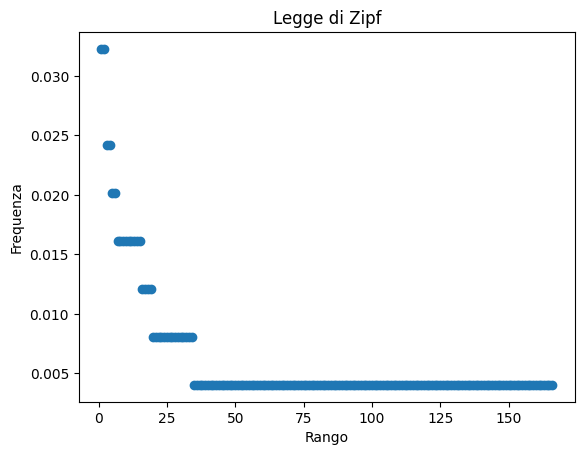

In [ ]:
plt.figure()
plt.scatter(df["rango"], df["frequenza_relativa"])
plt.xlabel("Rango")
plt.ylabel("Frequenza")
plt.title("Legge di Zipf")
plt.show()

### Osservazioni sulla distribuzione delle frequenze

Calcoliamo il numero di parole type con frequenza pari a uno, dette **hapax legomena**.

Cosa puoi osservare sia dal grafico che dal conteggio delle parole?

Scrivi qui le tue osservazioni

In [ ]:
num_hapax = (df["frequenza"] == 1).sum()
print(f"Numero di hapax {num_hapax}")
print(f"Percentuale di hapax {(num_hapax / l_corpus) * 100:.2f}%")

Numero di hapax 132
Percentuale di hapax 53.23%


Scrivi qui le tue osservazioni

### Equazione del grafico della legge di Zipf



Prova a ipotizzare l'equazione del grafico.

In [ ]:
# valori assunti dalla variabile indipendente
x = np.arange(1, len(df) + 1)

Inserisci qui l'equazione della funzione che secondo te meglio approssima la distribuzione delle frequenze.

In [ ]:
# esempio di funzione da modificare
# y = 20 + x

Confronta graficamente l'equazione da te ipotizzata con i dati reali.

NameError: name 'r' is not defined

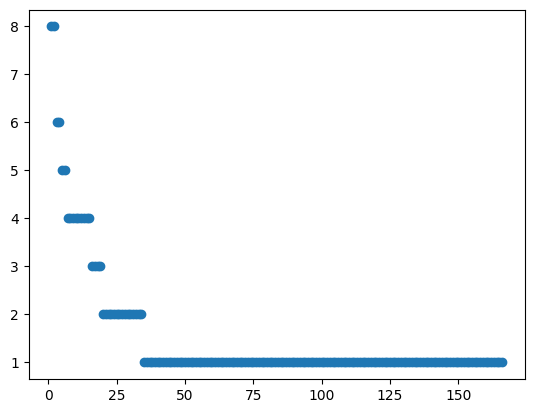

In [ ]:
# 6. Plot: scatter + iperbole
plt.figure()
plt.scatter(df["rango"], df["frequenza"], label="Dati reali")
plt.plot(r, y, linestyle="--", label="Legge di Zipf: C / r")

plt.xlabel("Rango")
plt.ylabel("Frequenza")
plt.title("Legge di Zipf: dati reali e curva teorica")
plt.legend()
plt.show()

Dopo aver scritto l'equazione del grafico della funzione, cioè la legge di Zipf, determina sia $ \lim_{x \to 0^+} f(x)$ che $ \lim_{x \to +∞} f(x)$. Quello che ottieni è in accordo con quanto osservato?

Scrvi qui le tue osservazioni